# Assignment 10: Semantic Image Segmentation using UNet

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import random_split
from tqdm.notebook import tqdm

ModuleNotFoundError: No module named 'tqdm'

In [2]:
# -- Generator to get unique figure ids --
def fig_id_generator():
    i = 1
    while True:
        yield i
        i += 1
fig_id = fig_id_generator()

In [3]:
class PetSegmentationDataset(Dataset):
    valid_extensions = ('.jpg', '.jpeg', '.png')

    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = [f for f in os.listdir(image_dir) if f.lower().endswith(self.valid_extensions)]
        self.target_size = (256, 256)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        # Assuming masks have the same filename but .png extension
        mask_path = os.path.join(self.mask_dir, img_name.split(".")[0] + ".png")
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)  # 1 - channel trimap (1 , 2 , 3)

        resize_transform = transforms.Resize(self.target_size)
        image = resize_transform(image)
        mask = resize_transform(mask)

        if self.transform:
            image = self.transform(image)
            # Ensure mask is converted to tensor and classes are 0 - indexed (0 , 1 , 2)
            mask = torch.as_tensor(np.array(mask), dtype=torch.long) - 1
            return image, mask


# Example Transformations
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Load Oxford-IIIT Pet dataset
data_dir = "./drive/MyDrive/AI ML Expt 10/"
image_dir = os.path.join(data_dir, "images")
mask_dir = os.path.join(data_dir, "annotations/trimaps")

dataset = PetSegmentationDataset(image_dir, mask_dir, transform=transform)

In [6]:
 # This allows cuDNN to profile and select the most efficient convolution algorithms
# for your specific input dimensions (256x256).
torch.backends.cudnn.benchmark = True

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Dataset loaded with 7390 items with split: Train 5173, Val 1108, Test 1109
Using device: cuda


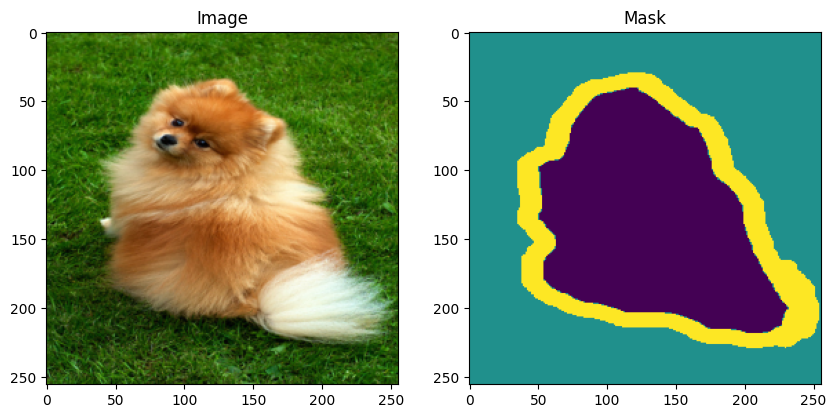

In [7]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

BATCH_SIZE = 16

NUM_WORKERS = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dataset loaded with {len(dataset)} items with split: Train {len(train_dataset)}, Val {len(val_dataset)}, Test {len(test_dataset)}")
print(f"Using device: {device}")

sample_image, sample_mask = dataset[0]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Image")
plt.imshow(sample_image.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5)

plt.subplot(1, 2, 2)
plt.title("Mask")
plt.imshow(sample_mask.cpu().numpy(), cmap="viridis")

plt.savefig(f"fig{next(fig_id)}.png", bbox_inches="tight")
plt.show()

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, use_bn=False, drop_p=0.0):
        super(DoubleConv, self).__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels) if use_bn else nn.Identity(),
            nn.ReLU(inplace=True),
        ]
        if drop_p > 0:
            layers.append(nn.Dropout(drop_p))
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=3, use_skip=True, use_bn=False, drop_p=0.0):
        super(UNet, self).__init__()
        self.use_skip = use_skip

        # Encoder
        self.enc1 = DoubleConv(in_channels, 64, use_bn=use_bn)
        self.enc2 = DoubleConv(64, 128, use_bn=use_bn)
        self.enc3 = DoubleConv(128, 256, use_bn=use_bn)
        self.enc4 = DoubleConv(256, 512, use_bn=use_bn)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024, use_bn=use_bn, drop_p=drop_p)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024 if use_skip else 512, 512, use_bn=use_bn)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512 if use_skip else 256, 256, use_bn=use_bn)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256 if use_skip else 128, 128, use_bn=use_bn)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128 if use_skip else 64, 64, use_bn=use_bn)

        self.out_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool(e1)
        e2 = self.enc2(p1)
        p2 = self.pool(e2)
        e3 = self.enc3(p2)
        p3 = self.pool(e3)
        e4 = self.enc4(p3)
        p4 = self.pool(e4)

        # Bottleneck
        b = self.bottleneck(p4)

        # Decoder
        d4 = self.up4(b)
        if self.use_skip:
            d4 = torch.cat((e4, d4), dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        if self.use_skip:
            d3 = torch.cat((e3, d3), dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        if self.use_skip:
            d2 = torch.cat((e2, d2), dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        if self.use_skip:
            d1 = torch.cat((e1, d1), dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)

In [9]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        num_classes = logits.shape[1]
        probs = F.softmax(logits, dim=1)

        # One-hot encode targets
        targets_one_hot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets_one_hot, dims)
        cardinality = torch.sum(probs + targets_one_hot, dims)

        dice_score = (2. * intersection + self.smooth) / (cardinality + self.smooth)
        return 1 - torch.mean(dice_score)

def calculate_metrics(outputs, targets, num_classes=3):
    preds = torch.argmax(outputs, dim=1)

    ious = torch.zeros(num_classes, device=outputs.device)
    dice_coeffs = torch.zeros(num_classes, device=outputs.device)

    for cls in range(num_classes):
        pred_cls = (preds == cls)
        target_cls = (targets == cls)

        intersection = (pred_cls & target_cls).float().sum()
        union = (pred_cls | target_cls).float().sum()

        # Optimization: Use torch.where to avoid branching and stay on GPU
        iou = torch.where(union == 0, torch.tensor(1.0, device=outputs.device), intersection / (union + 1e-7))
        dice = (2 * intersection) / (pred_cls.float().sum() + target_cls.float().sum() + 1e-7)

        ious[cls] = iou
        dice_coeffs[cls] = dice

    return ious.mean().item(), dice_coeffs.mean().item()

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, device='cpu'):
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, masks in tqdm(train_loader):
            images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
                outputs = model(images)
                loss = criterion(outputs, masks)
                running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}", flush=True)

    return train_losses, val_losses

def evaluate_model(model, test_loader, device='cpu'):
    model.eval()
    all_mious = []
    all_dice = []
    with torch.no_grad():
        for images, masks in test_loader:
            images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
            outputs = model(images)
            miou, dice = calculate_metrics(outputs, masks)
            all_mious.append(miou)
            all_dice.append(dice)

    return np.mean(all_mious), np.mean(all_dice)

def plot_curves(train_losses, val_losses, title):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig(f"fig{next(fig_id)}.png", bbox_inches="tight")
    plt.show()

Total Trainable Parameters: 31031875


  0%|          | 0/324 [00:00<?, ?it/s]

Epoch [1/30], Train Loss: 1.2116, Val Loss: 0.8489


  0%|          | 0/324 [00:00<?, ?it/s]

Epoch [2/30], Train Loss: 0.7442, Val Loss: 0.6913


...

Epoch [28/30], Train Loss: 0.1802, Val Loss: 0.3448


  0%|          | 0/324 [00:00<?, ?it/s]

Epoch [29/30], Train Loss: 0.1713, Val Loss: 0.3493


  0%|          | 0/324 [00:00<?, ?it/s]

Epoch [30/30], Train Loss: 0.1781, Val Loss: 0.3404


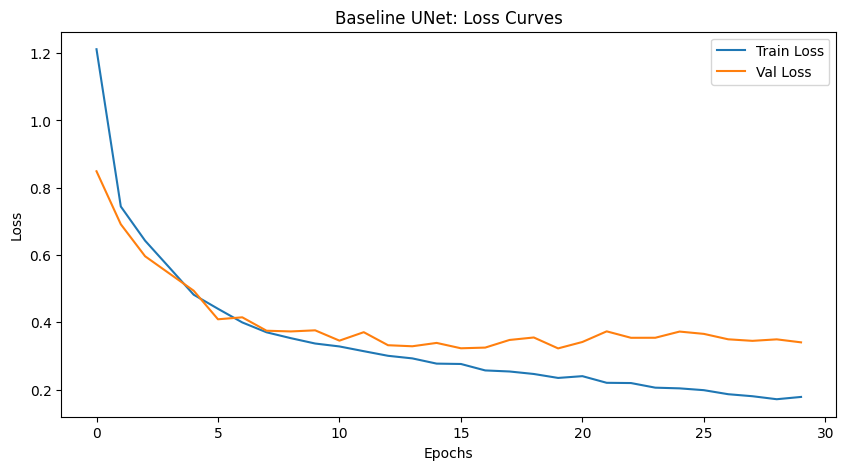

Test mIoU: 0.7270, Test Dice Coefficient: 0.8302


In [ ]:
# Experiment 1: Baseline UNet
model_1 = UNet(use_skip=True, use_bn=False, drop_p=0.0).to(device)
trainable_params_1 = sum(p.numel() for p in model_1.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {trainable_params_1}")

criterion_1 = nn.CrossEntropyLoss()
optimizer_1 = optim.Adam(model_1.parameters(), lr=0.001)

train_losses_1, val_losses_1 = train_model(model_1, train_loader, val_loader, criterion_1, optimizer_1, num_epochs=30, device=device)

plot_curves(train_losses_1, val_losses_1, "Baseline UNet: Loss Curves")
miou_1, dice_1 = evaluate_model(model_1, test_loader, device=device)
print(f"Test mIoU: {miou_1:.4f}, Test Dice Coefficient: {dice_1:.4f}")

Total Trainable Parameters: 27898435


  0%|          | 0/324 [00:00<?, ?it/s]

Epoch [1/30], Train Loss: 0.9544, Val Loss: 0.9263


  0%|          | 0/324 [00:00<?, ?it/s]

Epoch [2/30], Train Loss: 0.9283, Val Loss: 0.9177


...

Epoch [28/30], Train Loss: 0.9157, Val Loss: 0.9083


  0%|          | 0/324 [00:00<?, ?it/s]

Epoch [29/30], Train Loss: 0.9157, Val Loss: 0.9083


  0%|          | 0/324 [00:00<?, ?it/s]

Epoch [30/30], Train Loss: 0.9157, Val Loss: 0.9083


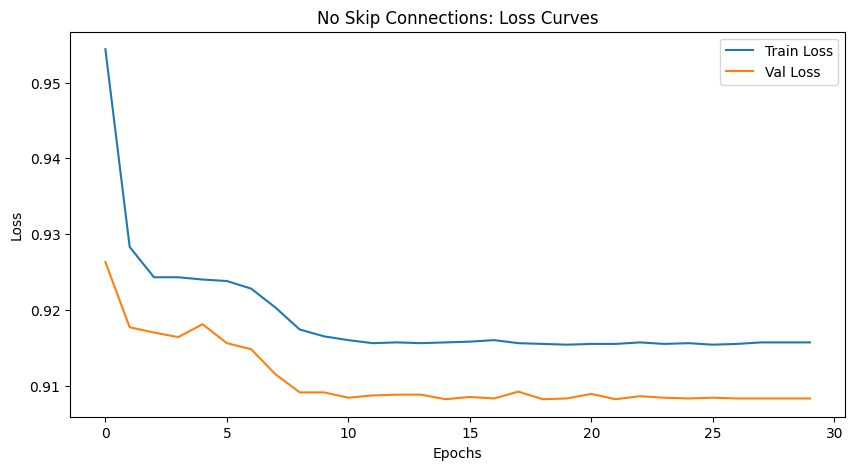

Test mIoU: 0.5376, Test Dice Coefficient: 0.6236


In [ ]:
# Experiment 2: Architectural Ablation (No Skip Connections)
model_2 = UNet(use_skip=False, use_bn=False, drop_p=0.0).to(device)
trainable_params_2 = sum(p.numel() for p in model_2.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {trainable_params_2}")

criterion_2 = nn.CrossEntropyLoss()
optimizer_2 = optim.Adam(model_2.parameters(), lr=0.001)

train_losses_2, val_losses_2 = train_model(model_2, train_loader, val_loader, criterion_2, optimizer_2, num_epochs=30, device=device)

plot_curves(train_losses_2, val_losses_2, "No Skip Connections: Loss Curves")
miou_2, dice_2 = evaluate_model(model_2, test_loader, device=device)
print(f"Test mIoU: {miou_2:.4f}, Test Dice Coefficient: {dice_2:.4f}")

In [11]:
# Experiment 3: Loss Function Ablation (Cross-Entropy + Dice Loss)
class CEDiceLoss(nn.Module):
    def __init__(self, ce_weight=1.0, dice_weight=1.0):
        super(CEDiceLoss, self).__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        return self.ce_weight * self.ce(logits, targets) + self.dice_weight * self.dice(logits, targets)

Total Trainable Parameters: 31031875


  0%|          | 0/324 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [1/30], Train Loss: 1.4943, Val Loss: 1.4164


  0%|          | 0/324 [00:00<?, ?it/s]

...

Epoch [28/30], Train Loss: 0.8274, Val Loss: 0.8430


  0%|          | 0/324 [00:00<?, ?it/s]

Epoch [29/30], Train Loss: 0.8204, Val Loss: 0.8657


  0%|          | 0/324 [00:00<?, ?it/s]

Epoch [30/30], Train Loss: 0.8119, Val Loss: 0.8359


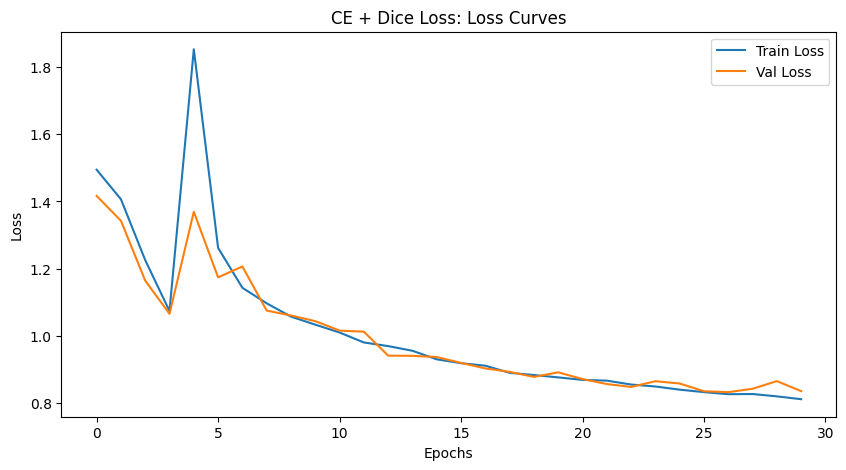

Test mIoU: 0.5873, Test Dice Coefficient: 0.7251


In [ ]:
model_3 = UNet(use_skip=True, use_bn=False, drop_p=0.0).to(device)
trainable_params_3 = sum(p.numel() for p in model_3.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {trainable_params_3}")

criterion_3 = CEDiceLoss()
optimizer_3 = optim.Adam(model_3.parameters(), lr=0.001)

train_losses_3, val_losses_3 = train_model(model_3, train_loader, val_loader, criterion_3, optimizer_3, num_epochs=30, device=device)

plot_curves(train_losses_3, val_losses_3, "CE + Dice Loss: Loss Curves")
miou_3, dice_3 = evaluate_model(model_3, test_loader, device=device)
print(f"Test mIoU: {miou_3:.4f}, Test Dice Coefficient: {dice_3:.4f}")

Total Trainable Parameters: 31043651


  0%|          | 0/324 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [1/30], Train Loss: 1.1507, Val Loss: 1.0363


  0%|          | 0/324 [00:00<?, ?it/s]

...

Epoch [28/30], Train Loss: 0.2814, Val Loss: 0.3905


  0%|          | 0/324 [00:00<?, ?it/s]

Epoch [29/30], Train Loss: 0.2759, Val Loss: 0.3912


  0%|          | 0/324 [00:00<?, ?it/s]

Epoch [30/30], Train Loss: 0.2688, Val Loss: 0.3828


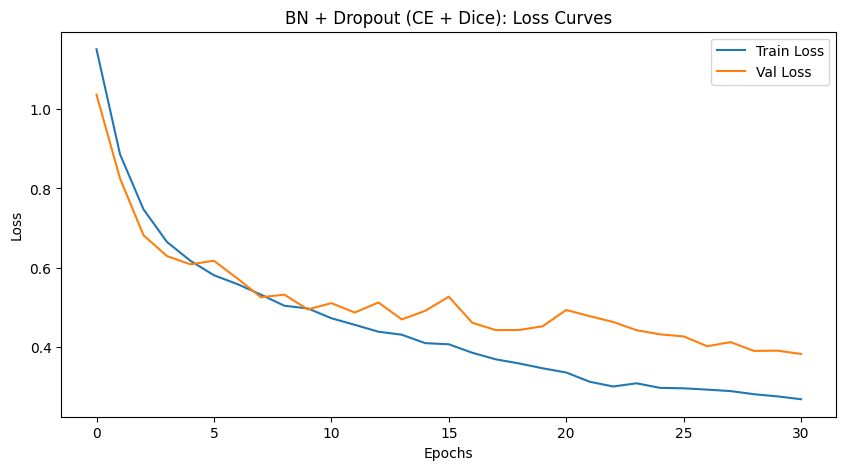

Test mIoU: 0.4638, Test Dice Coefficient: 0.7618

In [ ]:
# Experiment 4: Regularisation (Batch Normalisation & Dropout)
model_4 = UNet(use_skip=True, use_bn=True, drop_p=0.3).to(device)
trainable_params_4 = sum(p.numel() for p in model_4.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {trainable_params_4}")

# Using CEDiceLoss from Experiment 3
criterion_4 = CEDiceLoss()
optimizer_4 = optim.Adam(model_4.parameters(), lr=0.001)

train_losses_4, val_losses_4 = train_model(model_4, train_loader, val_loader, criterion_4, optimizer_4, num_epochs=30, device=device)

plot_curves(train_losses_4, val_losses_4, "BN + Dropout (CE + Dice): Loss Curves")
miou_4, dice_4 = evaluate_model(model_4, test_loader, device=device)
print(f"Test mIoU: {miou_4:.4f}, Test Dice Coefficient: {dice_4:.4f}")